This notebook plots Fig. 2A-J, S2E, and S3A-H and uses input from "1. snRNA-seq 1 - initial processing and input preparation". GO enrichment results were generated using Enrichr as described in the Methods; this notebook loads the resulting Enrichr output tables.


## Setup


In [1]:
# Set paths
SOD1_RENV_RNA="/oak/stanford/groups/agitler/Shared/Shared_Jupyter_Notebook_Analysis/4.1.1-OG-RNA/"
SOD1_RNA_DIR="/oak/stanford/groups/agitler/Shared/SOD1_Paper/RNA"

renv::load(SOD1_RENV_RNA)

# Load packages
suppressPackageStartupMessages({
  library(Seurat)
  library(SoupX)
  library(ggplot2)
  library(dplyr)
  library(BiocParallel)
  library(scDblFinder)
  library(svglite)
  library(pheatmap)
  library(matrixStats)
  library(tibble)
  library(DESeq2)
  library(VennDiagram)
  library(grid)
  library(stringr)
  library(ggrepel)
  library(ggrastr)
  library(ggpubr)
  library(forcats)
  library(ggbreak)
  library(cowplot)
  library(colorspace)
  library(broom)
  library(colorspace)
})

## Input Paths


In [2]:
# Checkpoint and result-table inputs
alpha_subset_file <- file.path(SOD1_RNA_DIR, "rds_files", "alpha_subset.rds")
alpha_label_transfer_file <- file.path(SOD1_RNA_DIR, "rds_files", "alpha_label_transfer_50.rds")

dm_vs_non_dm_file <- file.path(SOD1_RNA_DIR, "DESeq2", "Other.Clusters_vs_Cluster.2.csv")
alpha_early_disease_genes_file <- file.path(SOD1_RNA_DIR, "DESeq2", "Cholinergic_Type", "Alpha MNs_sod.early_vs_ctl.csv")
alpha_mid_disease_genes_file <- file.path(SOD1_RNA_DIR, "DESeq2", "Cholinergic_Type", "Alpha MNs_sod.mid_vs_ctl.csv")
alpha_end_disease_genes_file <- file.path(SOD1_RNA_DIR, "DESeq2", "Cholinergic_Type", "Alpha MNs_sod.end_vs_ctl.csv")
non_c2_alpha_early_disease_genes_file <- file.path(SOD1_RNA_DIR, "DESeq2", "Non-c2_Alpha_MNs", "Non-c2_Alpha_MNs_sod.early_vs_ctl.csv")
non_c2_alpha_mid_disease_genes_file <- file.path(SOD1_RNA_DIR, "DESeq2", "Non-c2_Alpha_MNs", "Non-c2_Alpha_MNs_sod.mid_vs_ctl.csv")
non_c2_alpha_end_disease_genes_file <- file.path(SOD1_RNA_DIR, "DESeq2", "Non-c2_Alpha_MNs", "Non-c2_Alpha_MNs_sod.end_vs_ctl.csv")
damn_up_go_file <- file.path(SOD1_RNA_DIR, "GO", "DAMN_up_GO_Biological_Process_2025.csv")
damn_down_go_file <- file.path(SOD1_RNA_DIR, "GO", "DAMN_down_GO_Biological_Process_2025.csv")
c9_c1_ff_alpha_file <- file.path(SOD1_RNA_DIR, "DESeq2", "C9_C1_FF_Alpha_MNs_sod1_vs_control.csv")
c0_c10_sf_alpha_file <- file.path(SOD1_RNA_DIR, "DESeq2", "C0_C10_SF_Alpha_MNs_sod1_vs_control.csv")
c9_c1_up_go_file <- file.path(SOD1_RNA_DIR, "GO", "C9_C1_Upregulated_GO_Biological_Process_2025.csv")
c9_c1_down_go_file <- file.path(SOD1_RNA_DIR, "GO", "C9_C1_Downregulated_GO_Biological_Process_2025.csv")

## Alpha MN UMAPs


In [3]:
# Load alpha MN RNA Seurat object
alpha_subset <- readRDS(file = alpha_subset_file)

In [4]:
# Base theme settings
common_theme <- theme(
  plot.title = element_text(hjust = 0.5, size = 11.56),
  axis.title = element_text(size = 11.56),
  axis.text  = element_text(size = 11.56),
  legend.text = element_text(size = 11.56),
  legend.title = element_text(size = 11.56),
  text = element_text(size = 11.56)
)

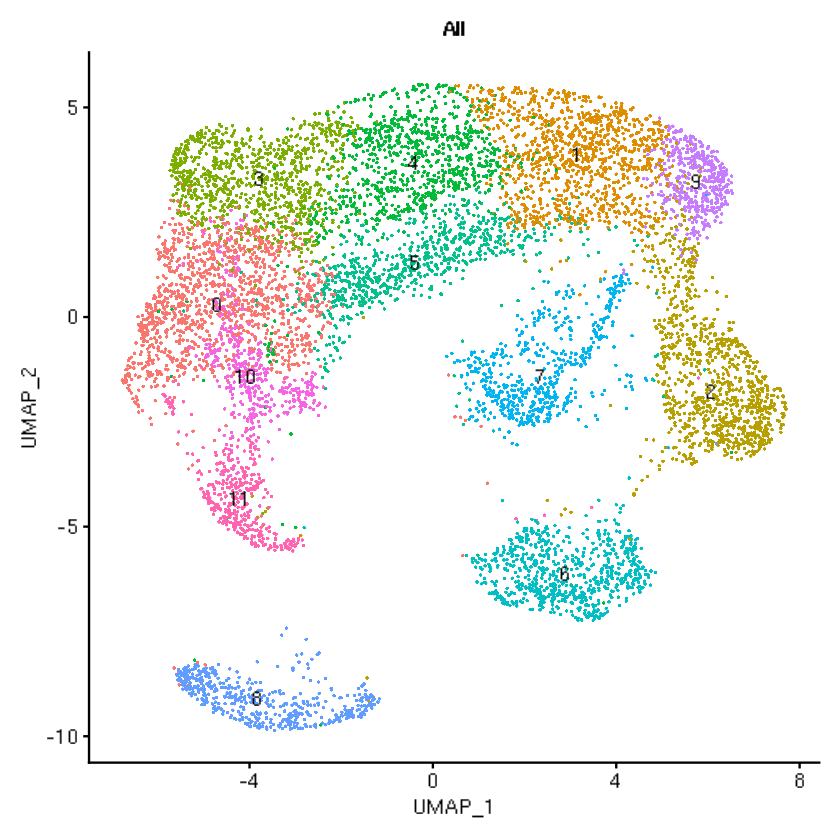

In [5]:
# All stages
alpha_subset_dimplot <- DimPlot(alpha_subset, reduction = "umap", label = TRUE) +
  NoLegend() +
  ggtitle("All") +
  common_theme

alpha_subset_dimplot <- rasterize(alpha_subset_dimplot, layers = "Point", dpi = 1000)
alpha_subset_dimplot

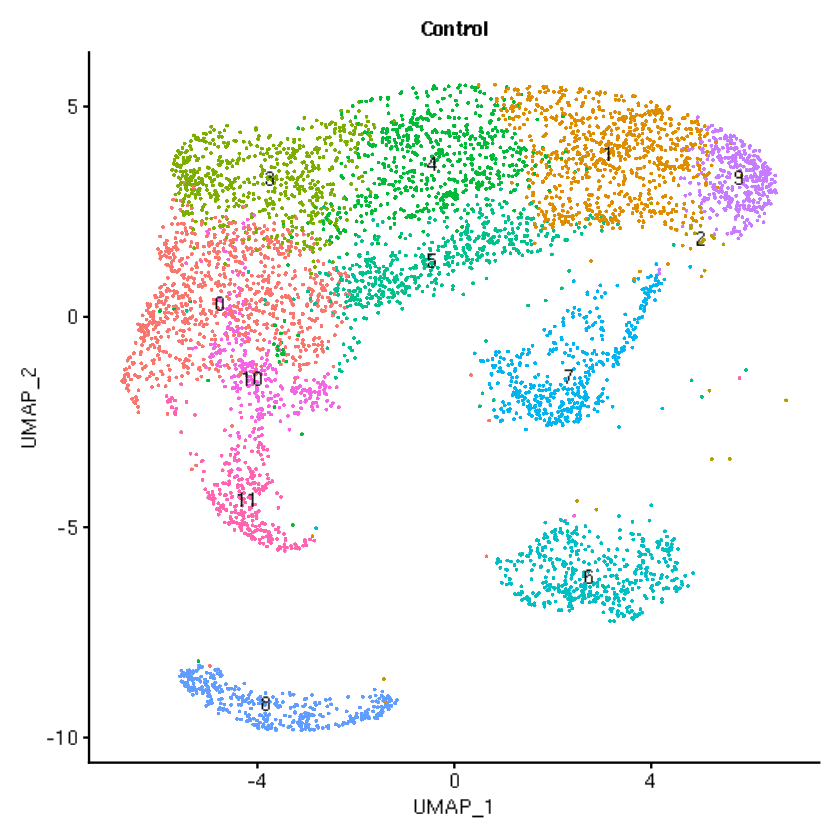

In [6]:
# Control only
alpha_ctl_dimplot <- DimPlot(
  subset(alpha_subset, stage == "ctl"),
  reduction = "umap",
  label = TRUE
) +
  NoLegend() +
  ggtitle("Control") +
  common_theme

alpha_ctl_dimplot <- rasterize(alpha_ctl_dimplot, layers = "Point", dpi = 1000)
alpha_ctl_dimplot

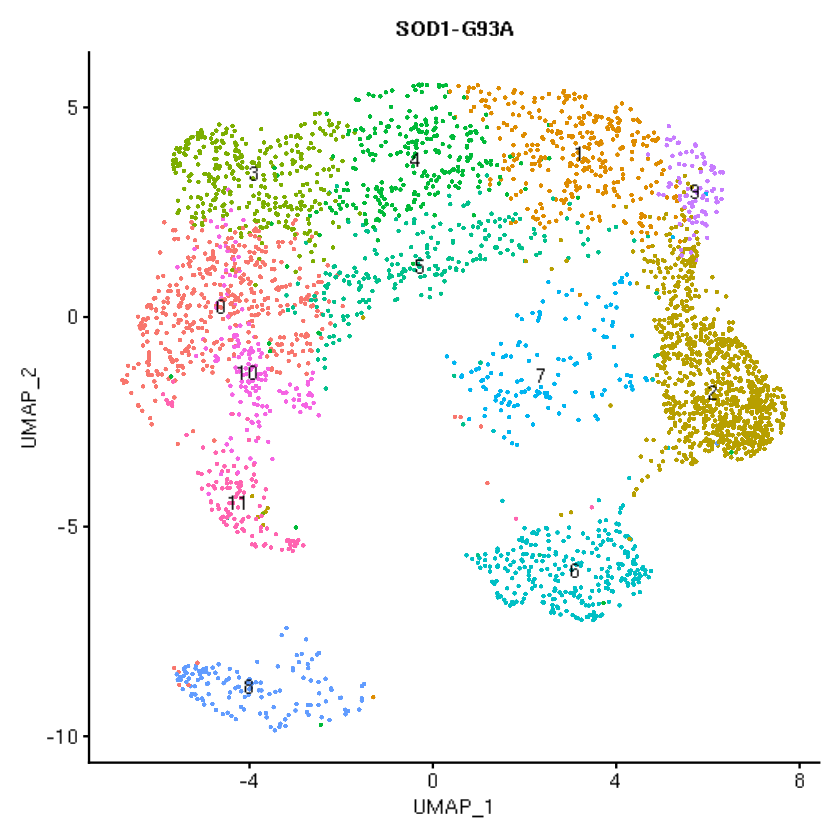

In [7]:
# SOD1-G93A only
alpha_sod1_dimplot <- DimPlot(
  subset(alpha_subset, stage %in% c("sod.early", "sod.mid", "sod.end")),
  reduction = "umap",
  label = TRUE
) +
  NoLegend() +
  ggtitle("SOD1-G93A") +
  common_theme

alpha_sod1_dimplot <- rasterize(alpha_sod1_dimplot, layers = "Point", dpi = 1000)
alpha_sod1_dimplot

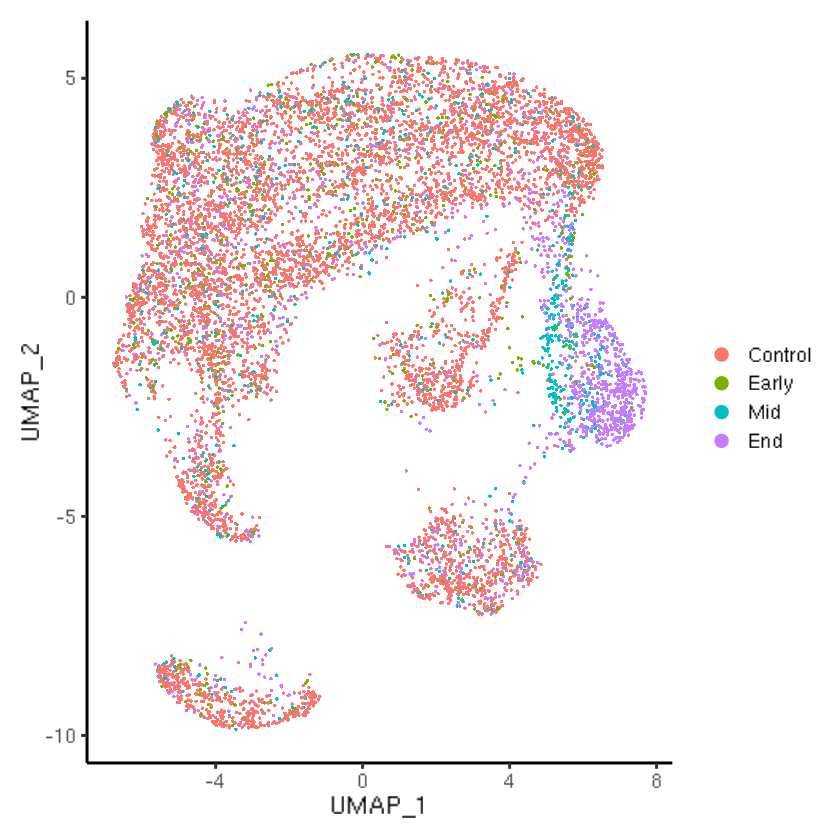

In [8]:
# Colored by stage

# Change labels
alpha_subset$stage <- factor(
  alpha_subset$stage,
  levels = c("ctl", "sod.early", "sod.mid", "sod.end"),
  labels = c("Control", "Early", "Mid", "End")
)

# Plot UMAP
p_umap <- DimPlot(
  alpha_subset,
  reduction = "umap",
  group.by = "stage",
  label = FALSE
) +
  labs(title = NULL, color = NULL) +  
  theme_classic(base_size = 14) +
  theme(
    plot.title = element_blank(),    
    legend.title = element_blank()    
  )

p_umap <- rasterize(p_umap, layers='Point', dpi=1000)
p_umap

## Cluster 2 / DM Proportion Plot


In [9]:
# Load alpha MN RNA Seurat object
alpha_subset <- readRDS(file = alpha_subset_file)

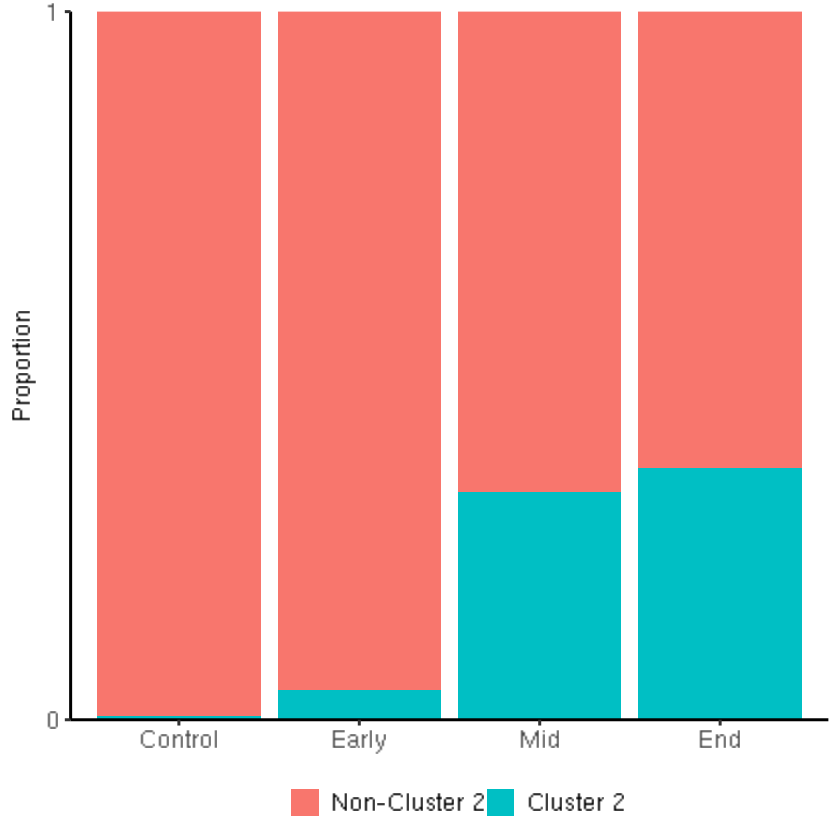

In [10]:
alpha_subset$c2 <- ifelse(alpha_subset$seurat_clusters == 2, "Cluster 2", "Non-Cluster 2")
alpha_subset$stage <- factor(alpha_subset$stage, levels = c("ctl", "sod.early", "sod.mid", "sod.end"))
alpha_subset$c2 <- factor(alpha_subset$c2, levels = c("Non-Cluster 2", "Cluster 2"))

stage_c2_proportion <- ggplot(alpha_subset@meta.data, aes(x = stage, fill = c2)) +
  geom_bar(position = "fill") +
  scale_y_continuous(breaks = c(0, 1), expand = c(0, 0)) +
  scale_x_discrete(labels = c("Control", "Early", "Mid", "End")) +
  ylab(expression("Proportion")) +
  scale_fill_discrete(name = NULL) +
  theme_classic(base_size = 14) +
  theme(
    axis.title.x = element_blank(),
    legend.position = "bottom",
    axis.text = element_text(size = 14),
    axis.title.y = element_text(size = 14),
    legend.text = element_text(size = 14),
    plot.title = element_text(size = 14, hjust = 0.5)
  )

stage_c2_proportion

In [11]:
metadata <- alpha_subset@meta.data

proportions <- metadata %>%
  group_by(stage) %>%
  summarise(
    total_nuclei = n(),
    cluster2_nuclei = sum(c2 == "Cluster 2"),
    proportion_cluster2 = cluster2_nuclei / total_nuclei
  )

proportions

stage,total_nuclei,cluster2_nuclei,proportion_cluster2
<fct>,<int>,<int>,<dbl>
ctl,5753,25,0.004345559
sod.early,678,28,0.041297935
sod.mid,814,261,0.320638821
sod.end,1984,704,0.354838710


## DM/Non-DM Correlation Heatmap


Warning message in PseudobulkExpression(object = object, pb.method = "average", :
“Exponentiation yielded infinite values. `data` may not be log-normed.”


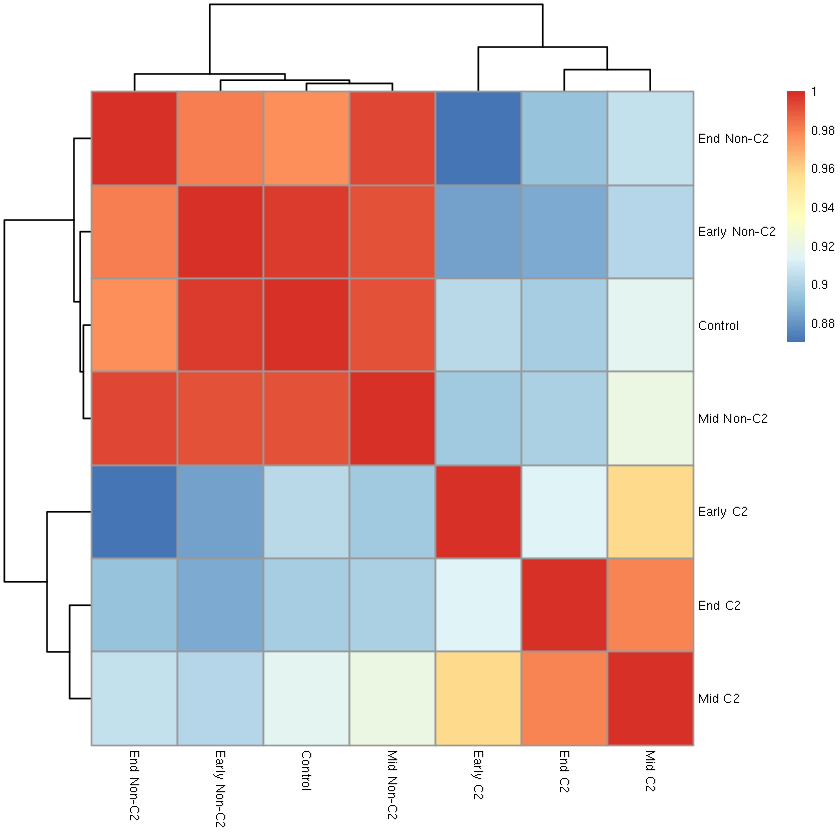

In [12]:
# Define groupings
alpha_subset$group <- case_when(
  alpha_subset$stage == "ctl" ~ "ctl",
  alpha_subset$stage == "sod.early" & alpha_subset$seurat_clusters == "2" ~ "sod.early_2",
  alpha_subset$stage == "sod.early" & alpha_subset$seurat_clusters != "2" ~ "sod.early_other",
  alpha_subset$stage == "sod.mid" & alpha_subset$seurat_clusters == "2" ~ "sod.mid_2",
  alpha_subset$stage == "sod.mid" & alpha_subset$seurat_clusters != "2" ~ "sod.mid_other",
  alpha_subset$stage == "sod.end" & alpha_subset$seurat_clusters == "2" ~ "sod.end_2",
  alpha_subset$stage == "sod.end" & alpha_subset$seurat_clusters != "2" ~ "sod.end_other"
)

# Compute average expression by group
avg_exp <- AverageExpression(alpha_subset, group.by = "group", return.seurat = FALSE)$RNA

# Keep variable genes
top_genes <- head(VariableFeatures(alpha_subset), 2000)
avg_exp_filtered <- avg_exp[rownames(avg_exp) %in% top_genes, ]

# Compute Pearson correlation matrix
cor_matrix <- cor(avg_exp_filtered)

# Rename rows/columns for better labeling
custom_labels <- c(
  "ctl" = "Control",
  "sod.early_2" = "Early C2",
  "sod.early_other" = "Early Non-C2",
  "sod.mid_2" = "Mid C2",
  "sod.mid_other" = "Mid Non-C2",
  "sod.end_2" = "End C2",
  "sod.end_other" = "End Non-C2"
)

colnames(cor_matrix) <- custom_labels[colnames(cor_matrix)]
rownames(cor_matrix) <- custom_labels[rownames(cor_matrix)]

# Plot heatmap
pheatmap(
  cor_matrix,
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  fontsize = 7,
)

## Atf3 and Gap43 Violin Plots


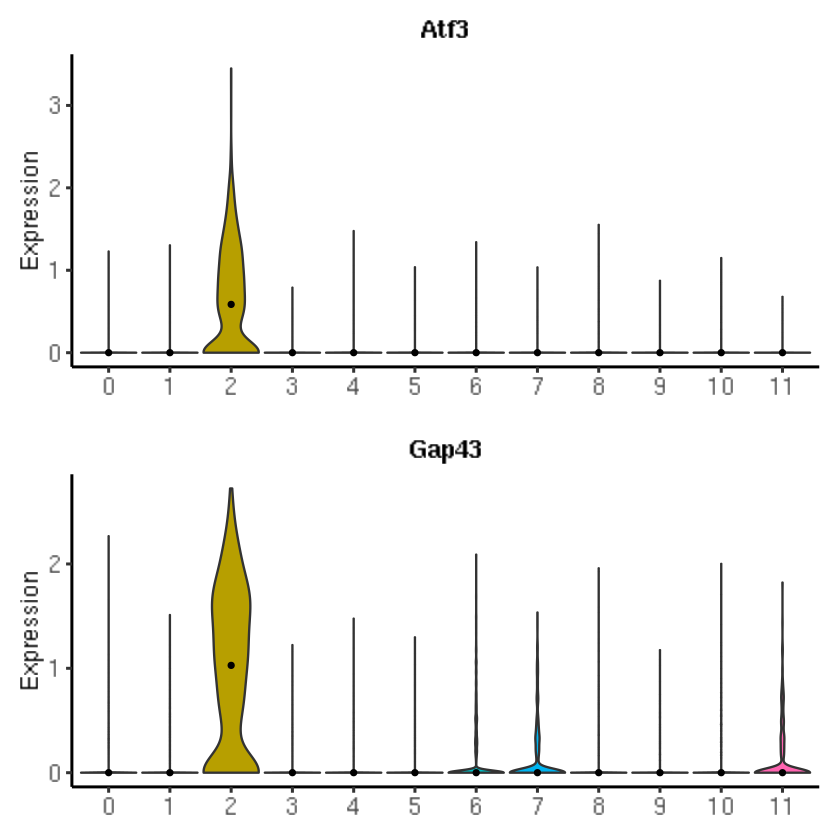

In [13]:
atf3_vln_plot <- VlnPlot(
  alpha_subset,
  features = "Atf3",
  group.by = "seurat_clusters",
  assay = "RNA",
  pt.size = 0
) +
  NoLegend() +
  stat_summary(fun = median, geom = "point", size = 1) +
  ggtitle("Atf3") +
  ylab("Expression") +
  theme_classic(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    axis.title.x = element_blank(),
    axis.title.y = element_text(size = 14),
    axis.text.x = element_text(size = 14),
    axis.text.y = element_text(size = 14),
    legend.position = "none"
  )

gap43_vln_plot <- VlnPlot(
  alpha_subset,
  features = "Gap43",
  group.by = "seurat_clusters",
  assay = "RNA",
  pt.size = 0
) +
  NoLegend() +
  stat_summary(fun = median, geom = "point", size = 1) +
  ggtitle("Gap43") +
  ylab("Expression") +
  theme_classic(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    axis.title.x = element_blank(),
    axis.title.y = element_text(size = 14),
    axis.text.x = element_text(size = 14),
    axis.text.y = element_text(size = 14),
    legend.position = "none"
  )

combined_vln_plots <- plot_grid(atf3_vln_plot, gap43_vln_plot, ncol = 1)
combined_vln_plots

## DM vs. Non-DM Volcano


In [14]:
make_volcano_plot <- function(data, labeled_pts=0, labeled_genes=NULL, p_val_cutoff=0.01) {
  data <- data %>%
    mutate(
      Expression = case_when(
        log2FoldChange >= 0 & padj <= p_val_cutoff ~ "Up-regulated",
        log2FoldChange <= 0 & padj <= p_val_cutoff ~ "Down-regulated",
        TRUE ~ "Unchanged"
      )
    )
  
  top <- labeled_pts
  top_genes <- bind_rows(
    data %>%
      filter(Expression == 'Up-regulated') %>%
      arrange(padj, desc(abs(log2FoldChange))) %>%
      head(top),
    data %>%
      filter(Expression == 'Down-regulated') %>%
      arrange(padj, desc(abs(log2FoldChange))) %>%
      head(top),
    data %>%
      filter(gene %in% labeled_genes)
  )
  
  x_scale <- max(abs(data$log2FoldChange), na.rm = TRUE)
  
  p1 <- ggplot(data, aes(log2FoldChange, -log10(padj))) +
    geom_point(aes(color = Expression), size = 4 / 5) +
    geom_label_repel(
      data = top_genes,
      mapping = aes(log2FoldChange, -log10(padj), label = gene),
      size = 4.5,
      force = 0.01
    ) +
    xlim(-x_scale, x_scale) +
    xlab(expression("log"[2]*"FC")) +
    ylab(expression("-log"[10]*"(padj)")) +
    scale_color_manual(values = c("dodgerblue3", "gray50", "firebrick3")) + 
    guides(colour = guide_legend(override.aes = list(size = 1.5))) + 
    theme_classic(base_size = 14) +
    theme(
      axis.text       = element_text(size = 14),
      axis.title      = element_text(size = 14),
      legend.text     = element_text(size = 14),
      legend.title    = element_text(size = 14),
      plot.title      = element_text(size = 14, hjust = 0.5),
      strip.text      = element_text(size = 14)
    )
  
  return(p1)
}

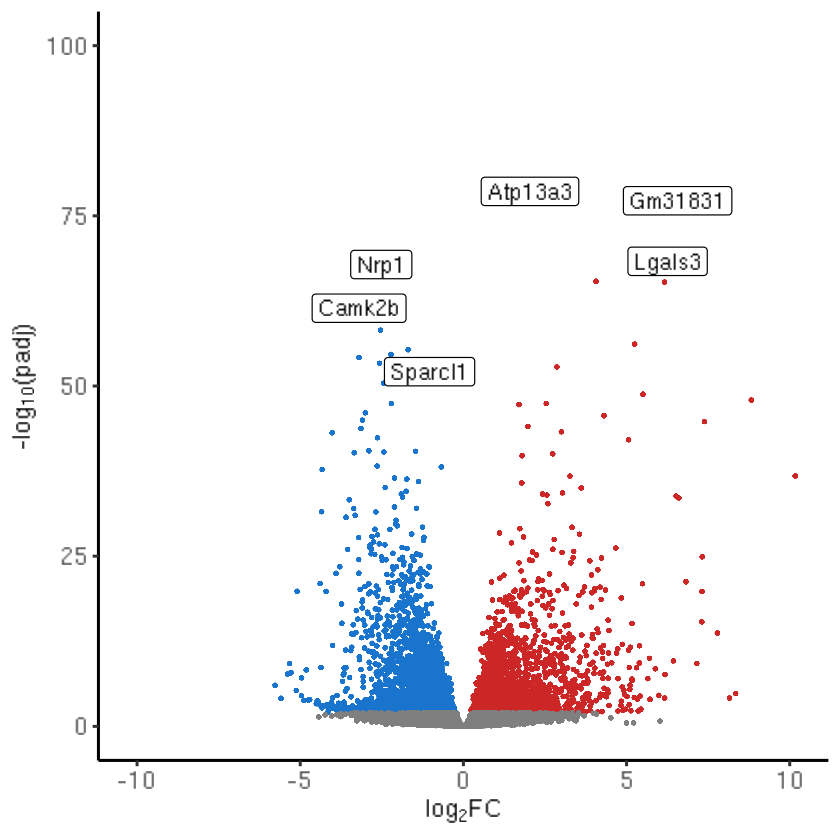

In [15]:
damn_vs_nonDamn <- read.csv(dm_vs_non_dm_file, row.names = 1)
damn_vs_nonDamn$gene <- rownames(damn_vs_nonDamn)
rownames(damn_vs_nonDamn) <- NULL
damn_vs_nonDamn$log2FoldChange <- damn_vs_nonDamn$log2FoldChange * -1

damn_vs_nonDamn_volcano_plot <- make_volcano_plot(
  damn_vs_nonDamn,
  labeled_pts = 3,
  p_val_cutoff = 0.01
) + ylim(0, 100)

damn_vs_nonDamn_volcano_plot <- rasterize(damn_vs_nonDamn_volcano_plot, layers = "Point", dpi = 1000) + NoLegend()
damn_vs_nonDamn_volcano_plot

## DEG Bar Plots

Scale for 'y' is already present. Adding another scale for 'y', which will
replace the existing scale.



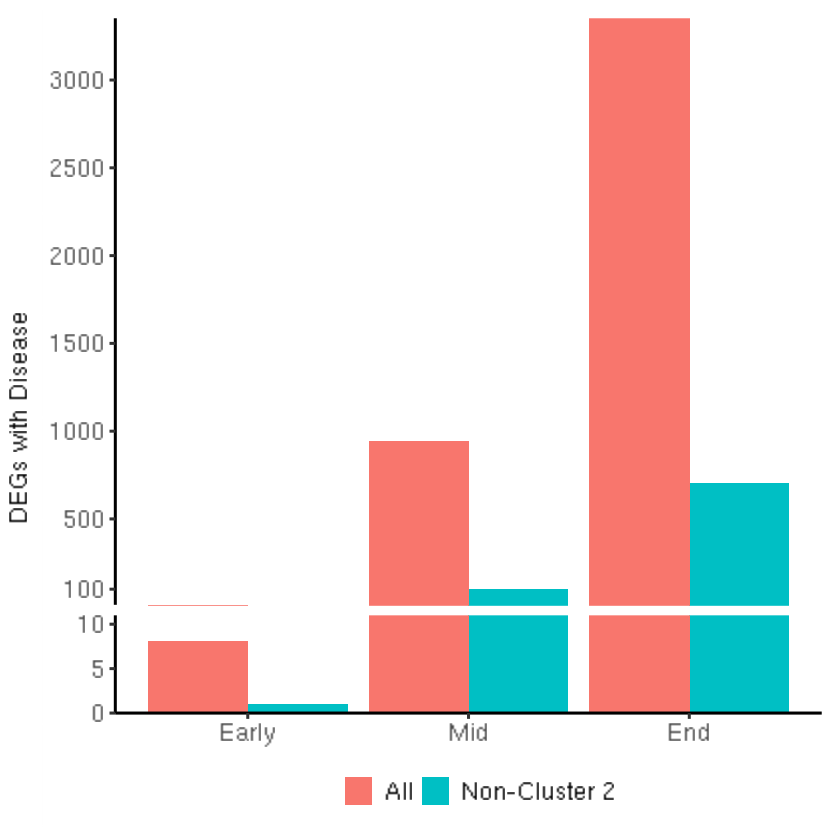

In [16]:
alpha_early_disease_genes <- read.csv(alpha_early_disease_genes_file, row.names = 1)
alpha_mid_disease_genes <- read.csv(alpha_mid_disease_genes_file, row.names = 1)
alpha_end_disease_genes <- read.csv(alpha_end_disease_genes_file, row.names = 1)

non_C2_alpha_early_disease_genes <- read.csv(non_c2_alpha_early_disease_genes_file, row.names = 1)
non_C2_alpha_mid_disease_genes <- read.csv(non_c2_alpha_mid_disease_genes_file, row.names = 1)
non_C2_alpha_end_disease_genes <- read.csv(non_c2_alpha_end_disease_genes_file, row.names = 1)

alpha_early_disease_genes_num_sig <- dplyr::filter(alpha_early_disease_genes, padj < 0.01) %>% nrow(.)
alpha_mid_disease_genes_num_sig <- dplyr::filter(alpha_mid_disease_genes, padj < 0.01) %>% nrow(.)
alpha_end_disease_genes_num_sig <- dplyr::filter(alpha_end_disease_genes, padj < 0.01) %>% nrow(.)

non_C2_alpha_early_disease_genes_num_sig <- dplyr::filter(non_C2_alpha_early_disease_genes, padj < 0.01) %>% nrow(.)
non_C2_alpha_mid_disease_genes_num_sig <- dplyr::filter(non_C2_alpha_mid_disease_genes, padj < 0.01) %>% nrow(.)
non_C2_alpha_end_disease_genes_num_sig <- dplyr::filter(non_C2_alpha_end_disease_genes, padj < 0.01) %>% nrow(.)

# Define stages
stages <- c("Early", "Mid", "End")

# Create data frames for both conditions
combined_df <- data.frame(
  stage     = rep(stages, 2),
  num_sig_genes = c(
    non_C2_alpha_early_disease_genes_num_sig,
    non_C2_alpha_mid_disease_genes_num_sig,
    non_C2_alpha_end_disease_genes_num_sig,
    alpha_early_disease_genes_num_sig,
    alpha_mid_disease_genes_num_sig,
    alpha_end_disease_genes_num_sig
  ),
  condition = rep(c("Non-Cluster 2", "All"), each = 3)
)

# Set stage factor levels
combined_df$stage <- factor(combined_df$stage, levels = stages)

p <- ggplot(combined_df, aes(x = stage, y = num_sig_genes, fill = condition)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  labs(
    x = "Stage",
    y = "DEGs with Disease",
    fill = "Condition"
  ) +
  theme_classic(base_size = 14) +
  scale_y_continuous(
    breaks = c(0, 5, 10, 100, 500, 1000, 1500, 2000, 2500, 3000),
    expand = c(0, 0)
  ) +
  theme(
    axis.title.x = element_blank(),
    legend.position = "bottom",
    legend.title = element_blank(),
    axis.text.x = element_text(size = 14),
    axis.text.y = element_text(size = 14),
    axis.title.y = element_text(size = 14),
    legend.text = element_text(size = 14),
    plot.title = element_text(size = 14, hjust = 0.5)
  )

# Add y-axis cut
p <- p + scale_y_cut(breaks = c(11), which = c(1, 2), scales = c(3, 0.5))
p

In [17]:
alpha_early_disease_genes_num_sig
alpha_mid_disease_genes_num_sig
alpha_end_disease_genes_num_sig

[1] 8

[1] 942

[1] 3352

In [18]:
non_C2_alpha_early_disease_genes_num_sig
non_C2_alpha_mid_disease_genes_num_sig
non_C2_alpha_end_disease_genes_num_sig

[1] 1

[1] 96

[1] 700

## DM vs. Non-DM GO Plots


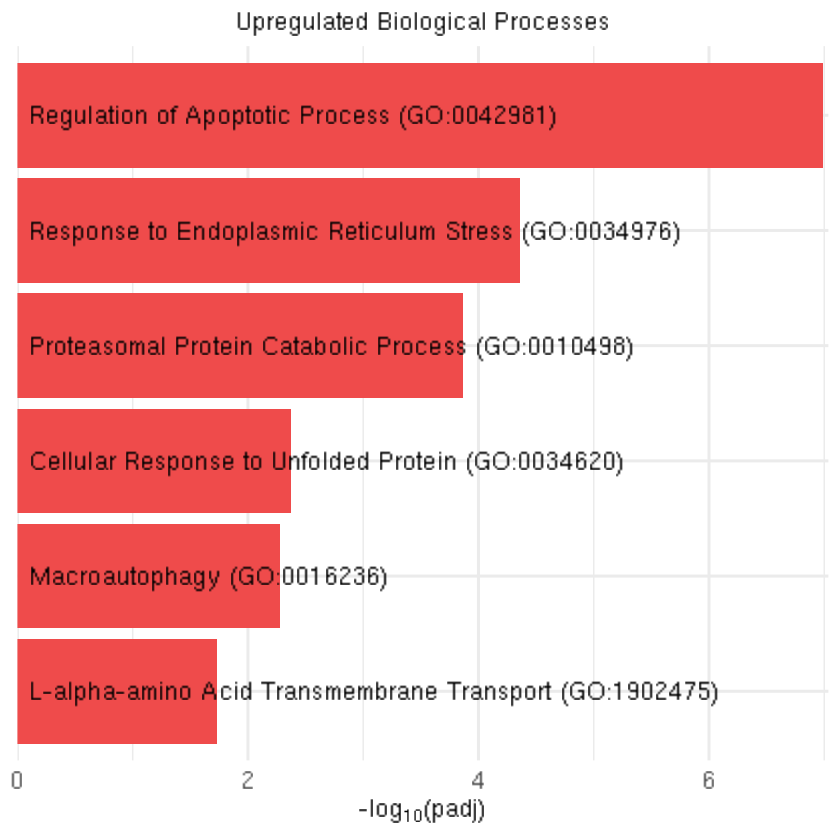

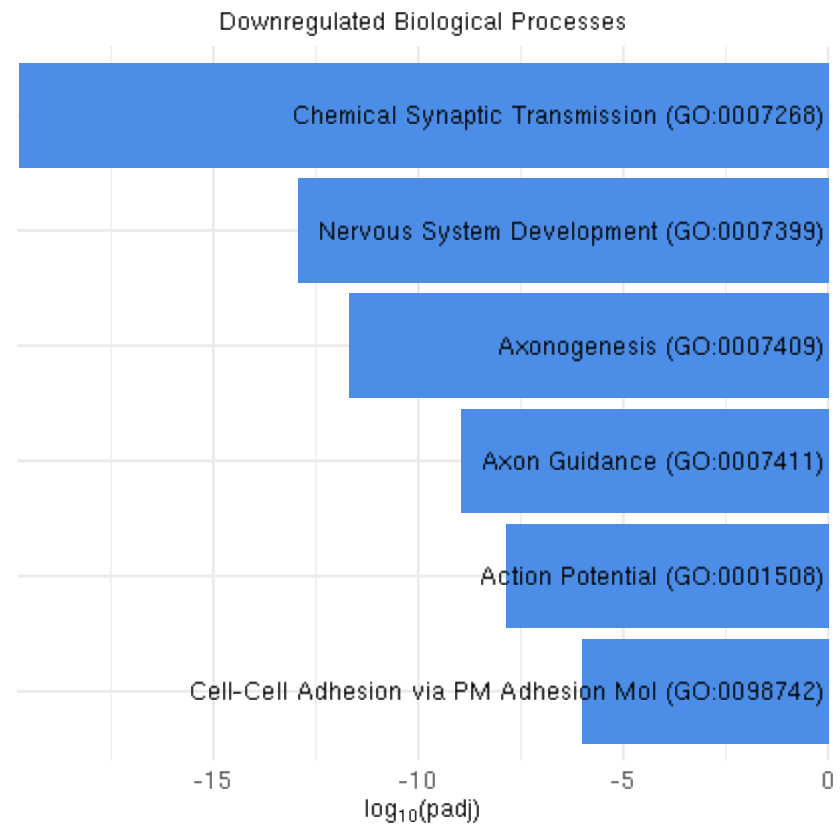

In [19]:
light_firebrick3  <- lighten("firebrick3",  0.2)
light_dodgerblue3 <- lighten("dodgerblue3", 0.2)

DAMN_up_GO_BP <- read.csv(damn_up_go_file)
DAMN_down_GO_BP <- read.csv(damn_down_go_file)

up_terms <- c(
  "Regulation of Apoptotic Process (GO:0042981)",
  "Response to Endoplasmic Reticulum Stress (GO:0034976)",
  "Proteasomal Protein Catabolic Process (GO:0010498)",
  "Cellular Response to Unfolded Protein (GO:0034620)",
  "Macroautophagy (GO:0016236)",
  "L-alpha-amino Acid Transmembrane Transport (GO:1902475)"
)

down_terms <- c(
  "Chemical Synaptic Transmission (GO:0007268)",
  "Nervous System Development (GO:0007399)",
  "Axonogenesis (GO:0007409)",
  "Axon Guidance (GO:0007411)",
  "Action Potential (GO:0001508)",
  "Cell-Cell Adhesion via Plasma-Membrane Adhesion Molecules (GO:0098742)"
)

# Get selected, significant terms
up_terms_df <- DAMN_up_GO_BP %>%
  dplyr::filter(Term %in% up_terms)

up_terms_df$Term <- fct_reorder(up_terms_df$Term, up_terms_df$Adjusted.P.value, .desc = TRUE)

# Get selected, significant terms
down_terms_df <- DAMN_down_GO_BP %>%
  dplyr::filter(Term %in% down_terms)

down_terms_df$Term <- fct_reorder(down_terms_df$Term, down_terms_df$Adjusted.P.value, .desc = TRUE)

# Rename long Term
down_terms_df <- down_terms_df %>%
  mutate(Term = recode(
    Term,
    "Cell-Cell Adhesion via Plasma-Membrane Adhesion Molecules (GO:0098742)" =
      "Cell-Cell Adhesion via PM Adhesion Mol (GO:0098742)"
  ))

DAMN_up_GO_BP_plot <- ggplot(up_terms_df, aes(x = -log10(Adjusted.P.value), y = Term)) +
  geom_col(fill = light_firebrick3) +
  geom_text(
    aes(x = 0.1, y = Term, label = Term),
    hjust = 0,
    vjust = 0.5,
    color = "black",
    inherit.aes = FALSE,
    size = 5
  ) +
  scale_x_continuous(expand = expansion(add = c(0, 0.05))) +
  ggtitle("Upregulated Biological Processes") +
  labs(
    x = expression("-log"[10]*"(padj)"),
    y = NULL
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.y = element_blank(),
    plot.title = element_text(hjust = 0.5, size = 14),
    axis.title.x = element_text(size = 14),
    axis.text.x = element_text(size = 14)
  )

DAMN_up_GO_BP_plot

DAMN_down_GO_BP_plot <- ggplot(down_terms_df, aes(x = log10(Adjusted.P.value), y = Term)) +
  geom_col(fill = light_dodgerblue3) +
  geom_text(
    aes(x = -0.1, y = Term, label = Term),
    hjust = 1,
    vjust = 0.5,
    color = "black",
    inherit.aes = FALSE,
    size = 5
  ) +
  scale_x_continuous(expand = expansion(add = c(0.05, 0))) +
  ggtitle("Downregulated Biological Processes") +
  labs(
    x = expression("log"[10]*"(padj)"),
    y = NULL
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.y = element_blank(),
    axis.text.x = element_text(size = 14),
    axis.title.x = element_text(size = 14),
    plot.title = element_text(hjust = 0.5, size = 14)
  )

DAMN_down_GO_BP_plot

## Selected DEG Heatmap

[1] 69

Warning message in PseudobulkExpression(object = object, pb.method = "average", :
“Exponentiation yielded infinite values. `data` may not be log-normed.”
Warning message:
“The following 43 features were not found in the integrated assay: Cntn4, Cadm2, Cadm1, Tenm1, Dscam, Il1rapl1, Adgrl3, Nlgn1, Lrrc4c, Lrfn5, Kcng1, Kcnj12, Kcnt1, Kcnn2, Kcna6, Kcnj3, Kcnj14, Nalcn, Kcnb1, Grin2d, Grik4, Grid2, Gria4, Gria2, Gabrb3, Gabra3, Gabrg2, Gabrb2, Gabbr2, Mapt, Stmn1, Ina, Slc7a5, Slc38a1, Slc1a4, Slc7a3, Slc6a9, Slc3a2, Slc38a2, Slc7a1, Slc7a6, Sqstm1, Taf15”


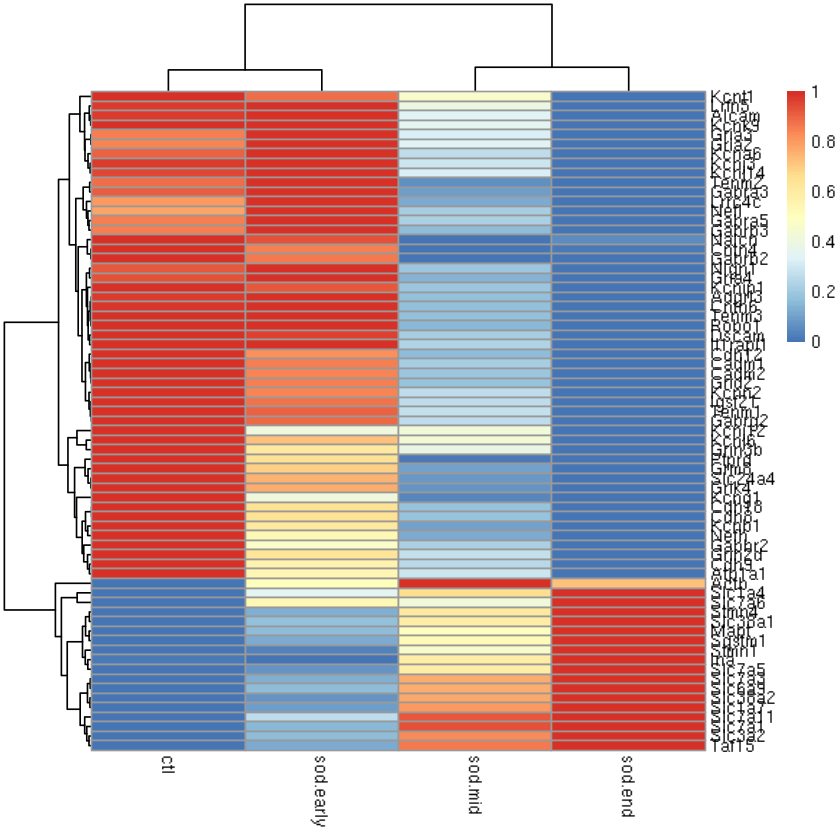

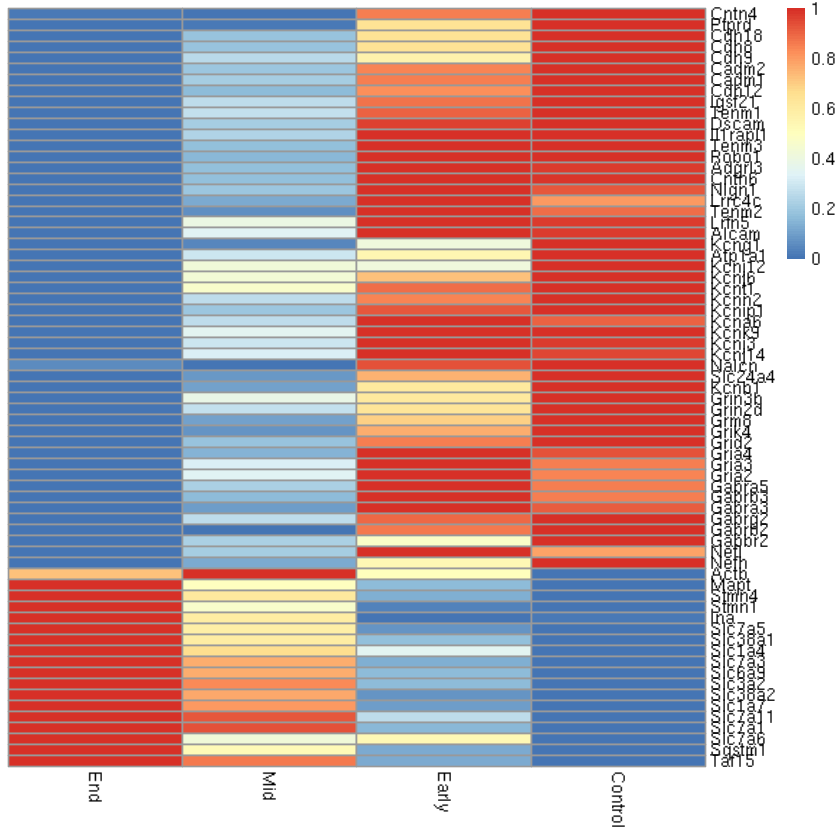

In [20]:
all.markers <- c("Cntn4","Ptprd","Cdh18","Cdh8","Cdh9","Cadm2","Cadm1","Cdh12","Igsf21","Tenm1","Dscam","Il1rapl1",
                 "Tenm3","Robo1","Adgrl3","Cntn6","Nlgn1","Lrrc4c","Tenm2","Lrfn5","Alcam",
                 "Kcng1","Atp1a1","Kcnj12","Kcnj6","Kcnt1","Kcnn2","Kcnip1","Kcna6","Kcnk9","Kcnj3","Kcnj14",
                 "Nalcn","Slc24a4","Kcnb1",
                 "Grin3b","Grin2d","Grm8","Grik4","Grid2","Gria4","Gria3","Gria2",
                 "Gabra5", "Gabrb3", "Gabra3", "Gabrg2", "Gabrb2", "Gabbr2",
                 "Nefl", "Nefh", "Actb", "Mapt", "Stmn4", "Stmn1", "Ina",
                 "Slc7a5","Slc38a1","Slc1a4","Slc7a3","Slc6a9","Slc3a2","Slc38a2","Slc1a7","Slc7a11","Slc7a1","Slc7a6",
                 "Sqstm1","Taf15")
length(all.markers)

Idents(alpha_subset) <- alpha_subset$stage
heatmap.avgexp <- AverageExpression(alpha_subset, features = all.markers)$RNA
heatmap.avgexp <- (heatmap.avgexp - rowMins(heatmap.avgexp)) / (rowMaxs(heatmap.avgexp) - rowMins(heatmap.avgexp))
pheatmap(heatmap.avgexp)

col_order <- c("sod.end", "sod.mid", "sod.early", "ctl")
heatmap.avgexp <- heatmap.avgexp[, col_order]

# Rename columns
colnames(heatmap.avgexp) <- c("End", "Mid", "Early", "Control")

row_order <- c("Cntn4","Ptprd","Cdh18","Cdh8","Cdh9","Cadm2","Cadm1","Cdh12","Igsf21","Tenm1","Dscam","Il1rapl1",
                 "Tenm3","Robo1","Adgrl3","Cntn6","Nlgn1","Lrrc4c","Tenm2","Lrfn5","Alcam",
                 "Kcng1","Atp1a1","Kcnj12","Kcnj6","Kcnt1","Kcnn2","Kcnip1","Kcna6","Kcnk9","Kcnj3","Kcnj14",
                 "Nalcn","Slc24a4","Kcnb1",
                 "Grin3b","Grin2d","Grm8","Grik4","Grid2","Gria4","Gria3","Gria2",
                 "Gabra5", "Gabrb3", "Gabra3", "Gabrg2", "Gabrb2", "Gabbr2",
                 "Nefl", "Nefh", "Actb", "Mapt", "Stmn4", "Stmn1", "Ina",
                 "Slc7a5","Slc38a1","Slc1a4","Slc7a3","Slc6a9","Slc3a2","Slc38a2","Slc1a7","Slc7a11","Slc7a1","Slc7a6",
                 "Sqstm1", "Taf15")
heatmap.avgexp <- heatmap.avgexp[row_order, ]

pheatmap(heatmap.avgexp, cluster_rows = FALSE, cluster_cols = FALSE)

## Non-C2 Alpha MN Proportions

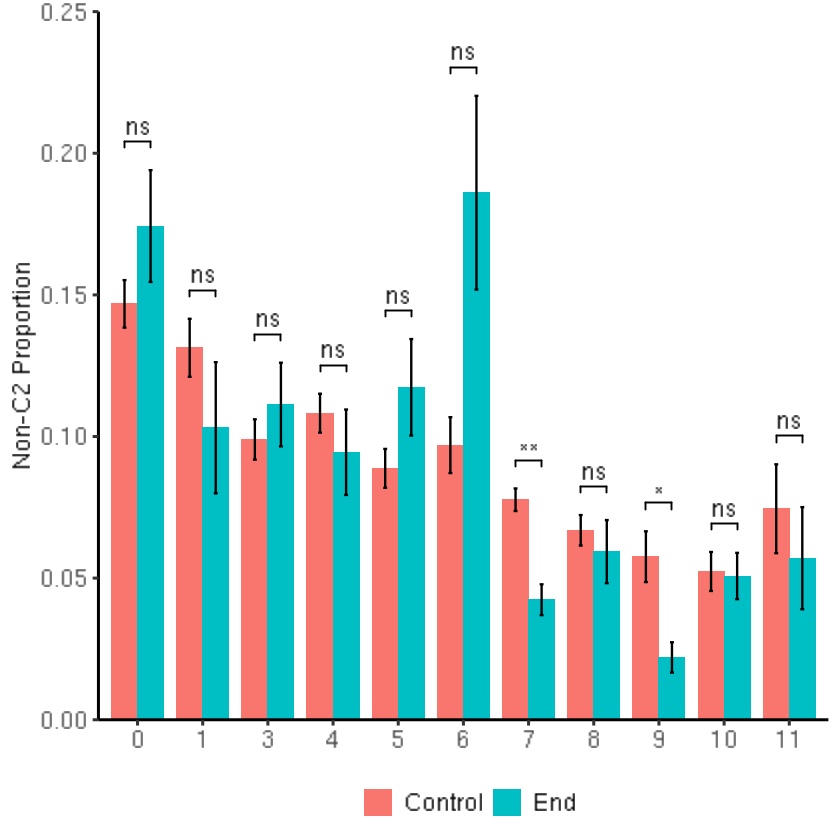

In [21]:
# Load alpha MN RNA Seurat object
alpha_subset <- readRDS(file = alpha_subset_file)

# Subset non-cluster 2/DAMN alpha MNs
alpha_non_c2 <- subset(alpha_subset, seurat_clusters != 2)

meta <- alpha_non_c2@meta.data

# Replicate-level proportions 
cluster_replicate <- meta %>%
  filter(stage %in% c("ctl", "sod.end")) %>%
  group_by(orig.ident, stage, seurat_clusters) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(orig.ident, stage) %>%
  mutate(proportion = count / sum(count)) %>%
  ungroup()

# Summary for bars (mean ± SEM)
summ_bars <- cluster_replicate %>%
  group_by(stage, seurat_clusters) %>%
  summarise(
    mean_prop = mean(proportion),
    sd_prop   = sd(proportion),
    n         = dplyr::n(),
    se_prop   = sd_prop / sqrt(n),
    .groups   = "drop"
  )

# Welch + BH/FDR per cluster 
test_df <- cluster_replicate %>%
  group_by(seurat_clusters) %>%
  group_modify(~{
    d <- .x
    g_counts <- table(d$stage)
    if (!all(c("ctl","sod.end") %in% names(g_counts)) || any(g_counts[c("ctl","sod.end")] < 2)) {
      return(tibble(method = NA_character_, p.value = NA_real_))
    }
    tst <- t.test(proportion ~ stage, data = d, var.equal = FALSE)  # Welch
    tibble(method = tst$method, p.value = tst$p.value)
  }) %>%
  ungroup() %>%
  mutate(
    p.adj        = p.adjust(p.value, method = "BH"),
    p.adj.signif = case_when(
      is.na(p.adj)  ~ "",
      p.adj < 0.001 ~ "***",
      p.adj < 0.01  ~ "**",
      p.adj < 0.05  ~ "*",
      TRUE          ~ "ns"
    )
  )

# Bracket y positions 
bracket_gap  <- 0.01   
y_max_limit  <- 0.25     
epsilon_clip <- 0.002    

y_pos <- summ_bars %>%
  group_by(seurat_clusters) %>%
  summarise(top_sem = max(mean_prop + se_prop, na.rm = TRUE), .groups = "drop") %>%
  mutate(y.position = pmin(top_sem + bracket_gap, y_max_limit - epsilon_clip))

# x-positions 
group_width <- 0.8              
bar_width   <- group_width / 2
delta       <- bar_width / 2     

cl_levels <- levels(factor(summ_bars$seurat_clusters))
cl_index  <- setNames(seq_along(cl_levels), cl_levels)

# Add numeric x for each bar (ctl left, sod.end right)
summ_bars_xy <- summ_bars %>%
  ungroup() %>%
  mutate(
    cluster_idx = cl_index[as.character(seurat_clusters)],
    x = ifelse(stage == "ctl",
               cluster_idx - delta,
               cluster_idx + delta)
  )

# Bracket endpoints use the same numeric positions
pval_df <- test_df %>%
  left_join(y_pos, by = "seurat_clusters") %>%
  filter(!is.na(p.adj)) %>%
  transmute(
    seurat_clusters,
    y.position,
    p.adj.signif,
    group1 = "ctl",
    group2 = "sod.end",
    cluster_idx = cl_index[as.character(seurat_clusters)],
    xmin = cluster_idx - delta,   
    xmax = cluster_idx + delta    
  )

# Add edge whitespace on x-axis 
n_clust  <- length(cl_levels)
edge_pad <- 0.2
x_limits <- c(1 - group_width/2 - edge_pad,
              n_clust + group_width/2 + edge_pad)

# Plot 
alpha_props <- ggplot(summ_bars_xy, aes(x = x, y = mean_prop, fill = stage)) +
  geom_col(width = bar_width) +
  geom_errorbar(aes(ymin = mean_prop - se_prop, ymax = mean_prop + se_prop),
                width = bar_width * 0.15) +
  ggpubr::stat_pvalue_manual(
    pval_df,
    label         = "p.adj.signif",
    y.position    = "y.position",
    xmin          = "xmin",
    xmax          = "xmax",
    bracket.size  = 0.4,
    tip.length    = 0.01,
    step.increase = 0,
    hide.ns       = FALSE,
    inherit.aes   = FALSE,
    size          = 14 / ggplot2::.pt   
  ) +
  scale_x_continuous(
    limits = x_limits,
    breaks = seq_len(n_clust),
    labels = cl_levels,
    expand = c(0, 0)
  ) +
  scale_fill_discrete(labels = c("ctl" = "Control", "sod.end" = "End")) +
  scale_y_continuous(limits = c(0, y_max_limit), expand = c(0, 0)) +
  labs(x = NULL, y = "Non-C2 Proportion", fill = NULL) +
  theme_classic(base_size = 14) +
  theme(
    text            = element_text(size = 14),
    axis.title      = element_text(size = 14),
    axis.text       = element_text(size = 14),
    legend.text     = element_text(size = 14),
    legend.title    = element_blank(),
    legend.position = "bottom",
    strip.background = element_blank(),
    strip.text      = element_text(face = "bold", size = 14),
    axis.text.x     = element_text(angle = 0, hjust = 0.5)
  )

alpha_props

In [22]:
# Number of replicates per stage
n_reps <- cluster_replicate %>%
  dplyr::distinct(orig.ident, stage) %>%
  dplyr::count(stage, name = "n_replicates")

n_reps

stage,n_replicates
<chr>,<int>
ctl,11
sod.end,6


## Alpha MN Marker Gene UMAPs

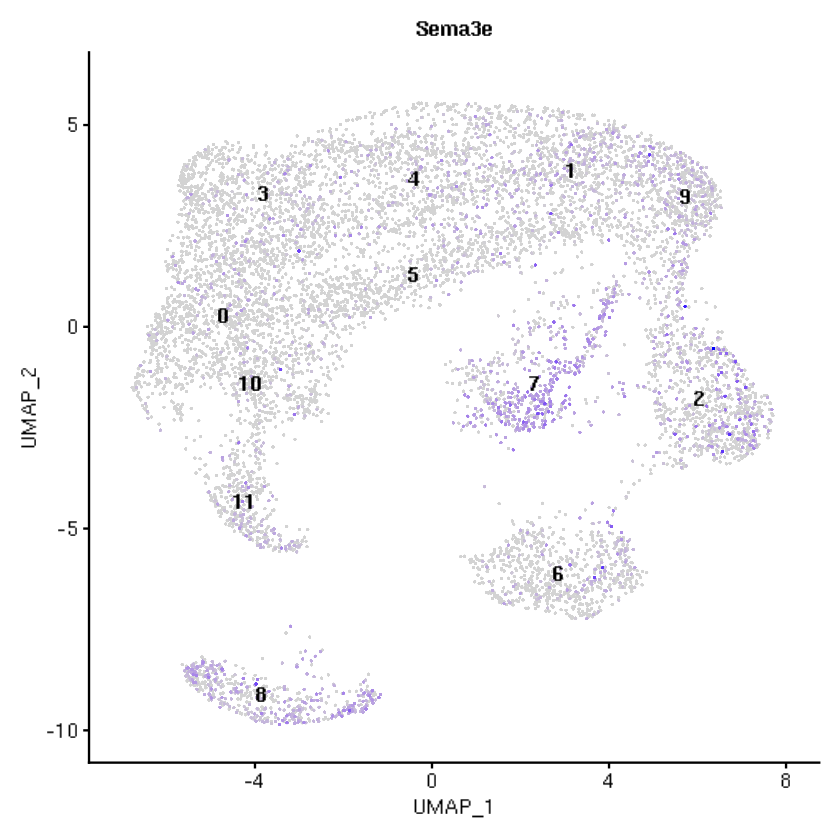

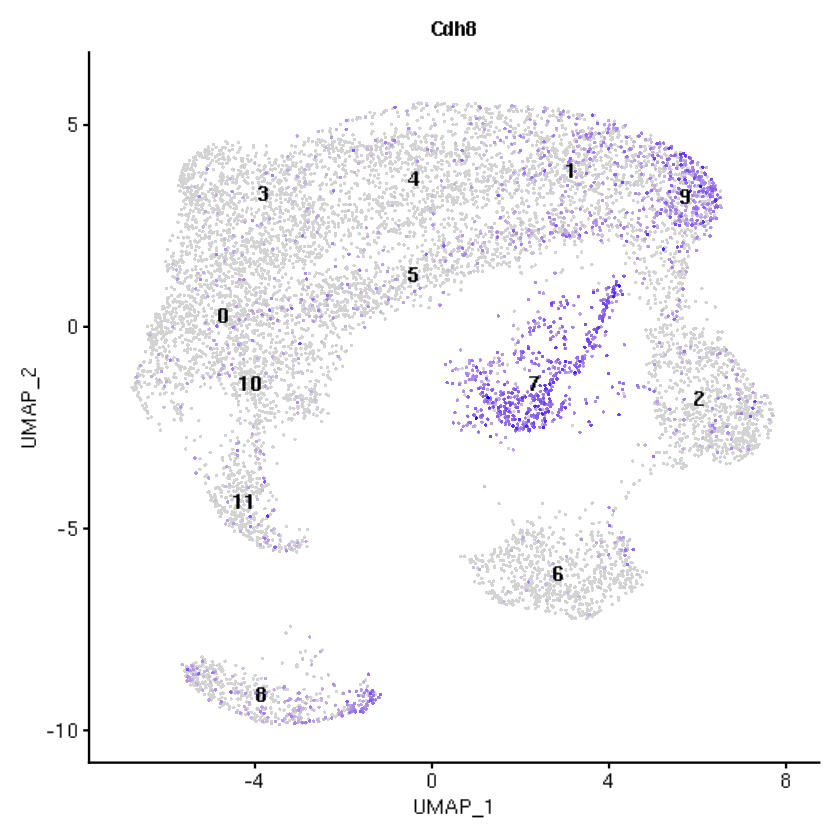

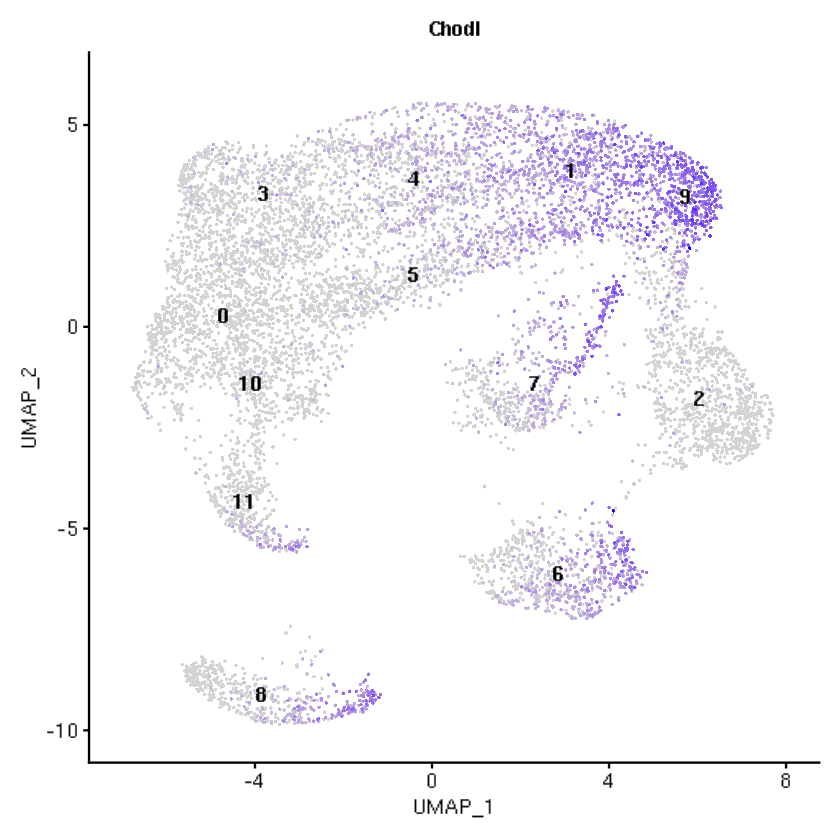

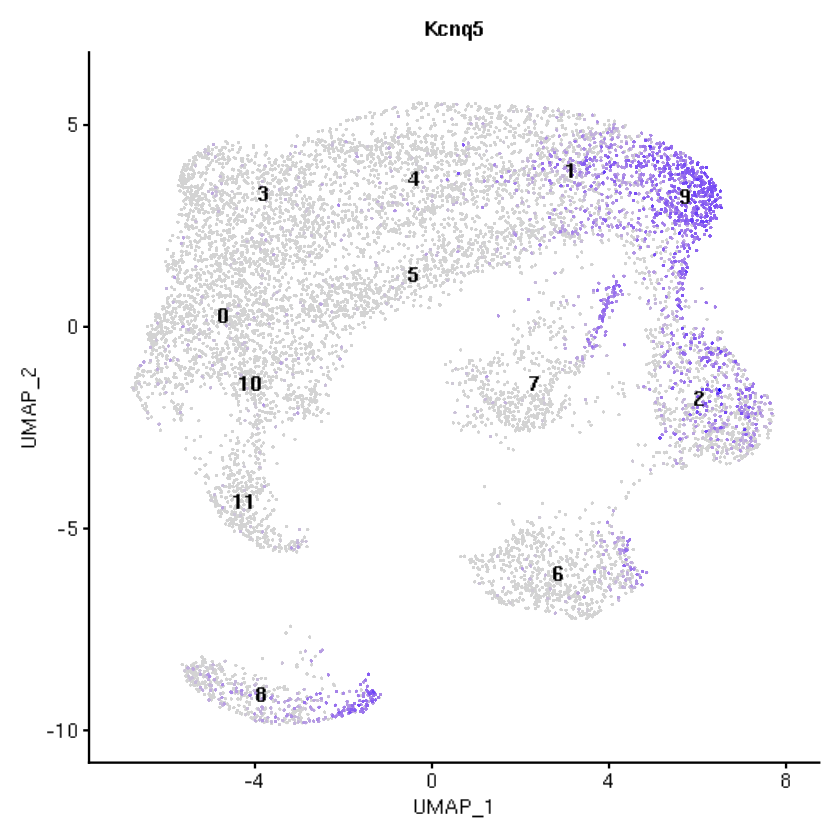

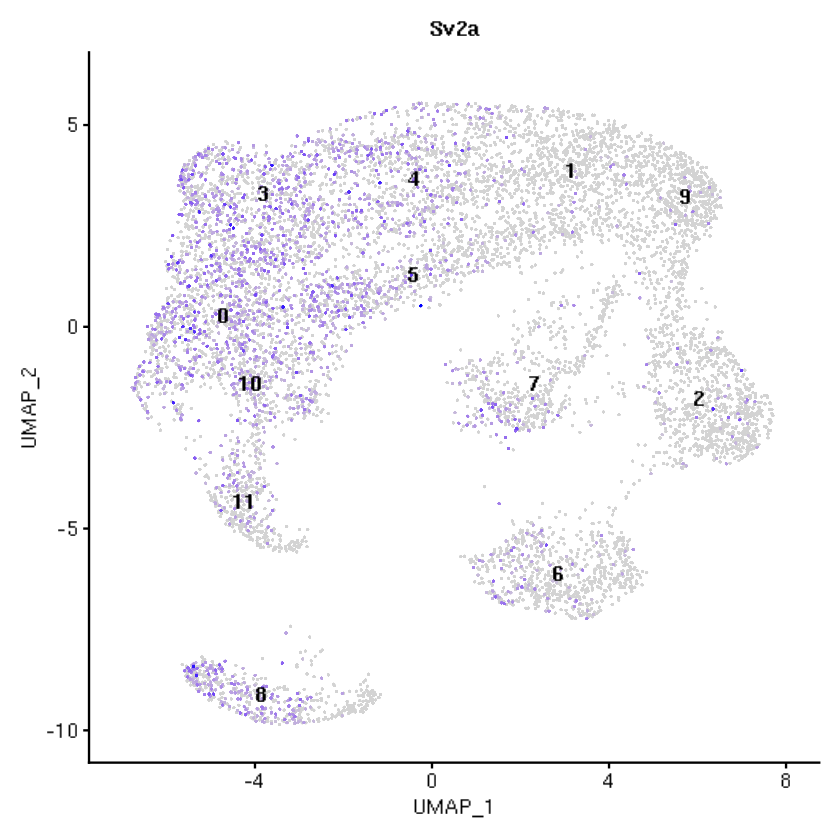

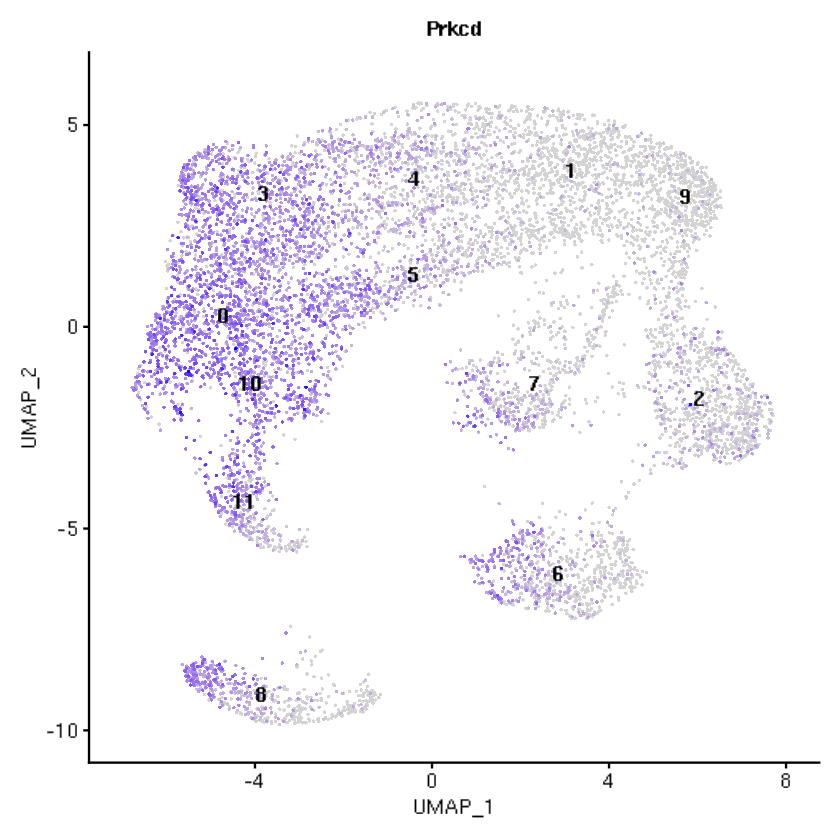

In [23]:
# Load alpha MN RNA Seurat object
alpha_subset <- readRDS(file = alpha_subset_file)
DefaultAssay(alpha_subset) <- "RNA"

# Base theme
common_theme <- theme(
  plot.title   = element_text(hjust = 0.5, size = 11.56),
  axis.title   = element_text(size = 11.56),
  axis.text    = element_text(size = 11.56),
  text         = element_text(size = 11.56)
)

genes_to_plot  <- c("Sema3e", "Cdh8", "Chodl", "Kcnq5", "Sv2a", "Prkcd")
genes_present  <- genes_to_plot[genes_to_plot %in% rownames(alpha_subset)]

# Compute cluster centers on UMAP once 
umap_df <- Embeddings(alpha_subset, "umap") %>%
  as.data.frame()
# Use seurat_clusters from metadata 
umap_df$seurat_clusters <- as.character(alpha_subset$seurat_clusters)

cluster_centers <- umap_df %>%
  group_by(seurat_clusters) %>%
  summarise(
    UMAP_1 = median(UMAP_1, na.rm = TRUE),
    UMAP_2 = median(UMAP_2, na.rm = TRUE),
    .groups = "drop"
  )

# Create and print plots
gene_plots <- list()
for (g in genes_present) {
  p <- FeaturePlot(
    alpha_subset,
    features  = g,
    reduction = "umap",
    order     = TRUE
  ) +
    ggtitle(g) +
    common_theme +
    NoLegend() +
    geom_text(
      data = cluster_centers,
      aes(x = UMAP_1, y = UMAP_2, label = seurat_clusters),
      inherit.aes = FALSE,
      size = 11.56 / ggplot2::.pt,
      fontface = "bold",
      color = "black"
    )

  # Rasterize 
  p <- rasterize(p, layers = "Point", dpi = 1000)

  gene_plots[[g]] <- p
  assign(g, p, envir = .GlobalEnv)
  print(p)
}

## C9/C1 vs. C0/C10 Venn Diagrams


In [24]:
c9_c1 <- read.csv(c9_c1_ff_alpha_file, row.names = 1)
c0_c10 <- read.csv(c0_c10_sf_alpha_file, row.names = 1)

c9_c1$gene <- rownames(c9_c1)
c0_c10$gene <- rownames(c0_c10)

c9_c1_up <- dplyr::filter(c9_c1, log2FoldChange > 0 & padj < 0.01)
c0_c10_up <- dplyr::filter(c0_c10, log2FoldChange > 0 & padj < 0.01)

c9_c1_down <- dplyr::filter(c9_c1, log2FoldChange < 0 & padj < 0.01)
c0_c10_down <- dplyr::filter(c0_c10, log2FoldChange < 0 & padj < 0.01)

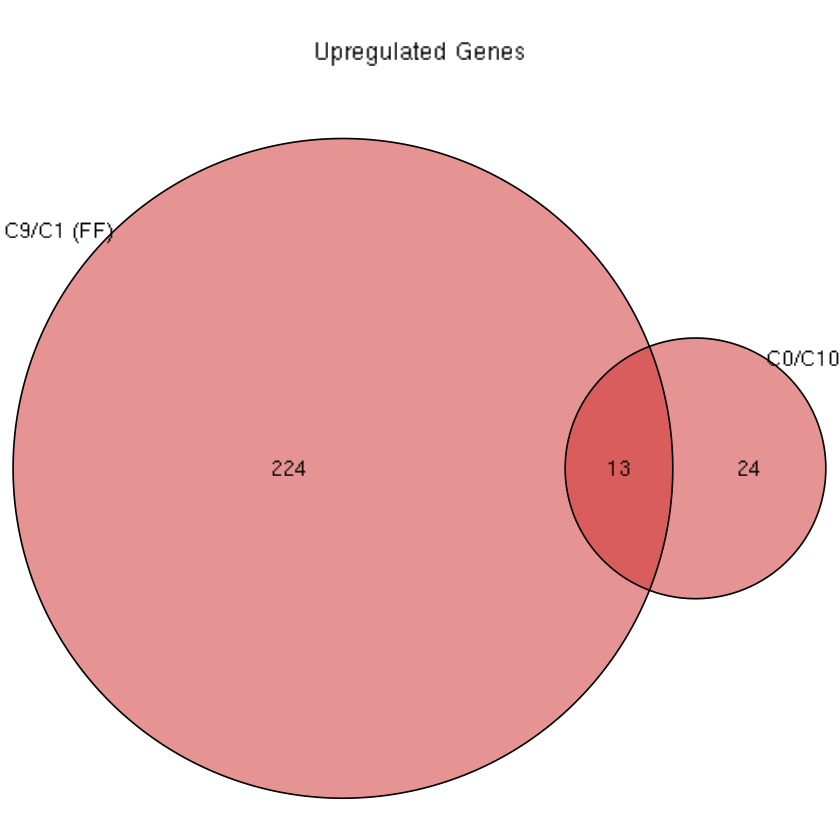

In [25]:
venn.plot.up <- venn.diagram(
  x = list(set1 = c9_c1_up$gene, set2 = c0_c10_up$gene),
  category.names = c("C9/C1 (FF)", "C0/C10 (SF)"),
  filename = NULL,
  main = "Upregulated Genes",
  main.cex = 14 / 12,
  main.pos = c(0.5, 0.98),
  main.just = c("center", "top"),
  margin = 0.02,
  col  = c("black", "black"),
  fill = c("firebrick3", "firebrick3"),
  alpha = 0.5,
  lwd = 1
)

grid.draw(venn.plot.up)

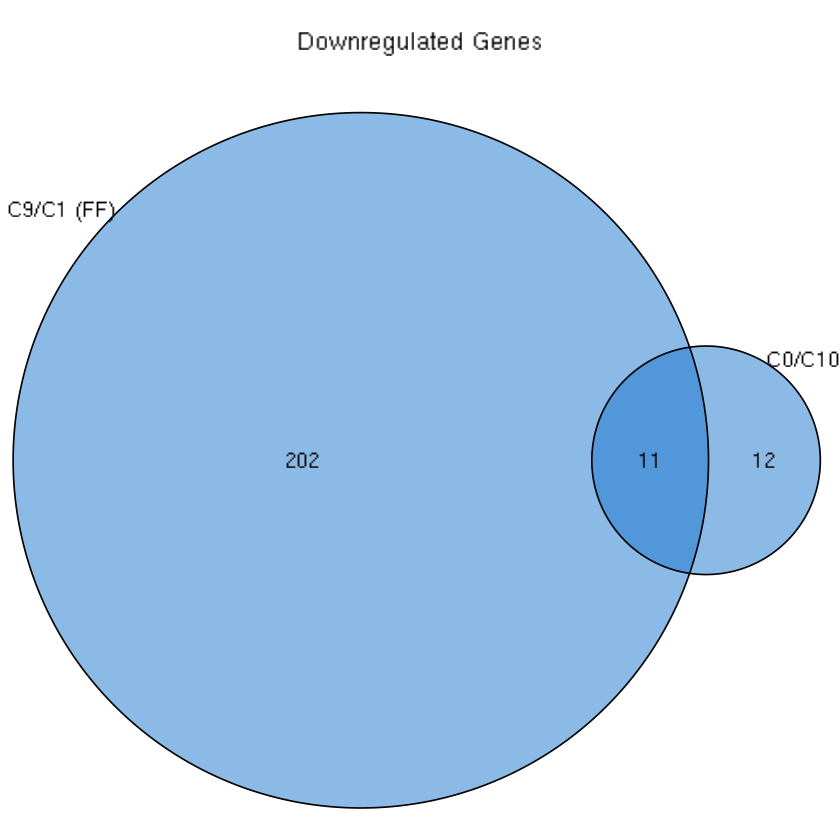

In [26]:
venn.plot.down <- venn.diagram(
  x = list(set1 = c9_c1_down$gene, set2 = c0_c10_down$gene),
  category.names = c("C9/C1 (FF)", "C0/C10 (SF)"),
  filename = NULL,
  main = "Downregulated Genes",
  main.cex = 14 / 12,
  main.pos = c(0.5, 0.98),
  main.just = c("center", "top"),
  margin = 0.02,
  col  = c("black", "black"),
  fill = c("dodgerblue3", "dodgerblue3"),
  alpha = 0.5,
  lwd = 1
)

grid.draw(venn.plot.down)

## Selected FF/SF Shared DEG Heatmap


[1] 22

Warning message:
“The following 8 features were not found in the integrated assay: Etv4, Nars, Camk1, Ifrd1, Dyrk3, Rasa4, Adamts17, Ccdc85a”


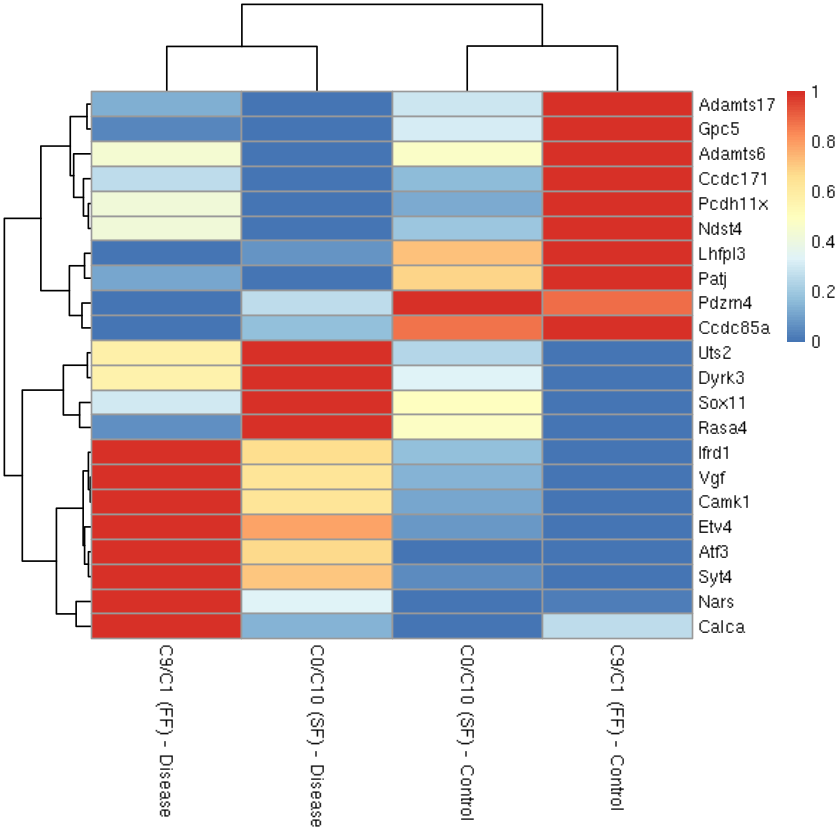

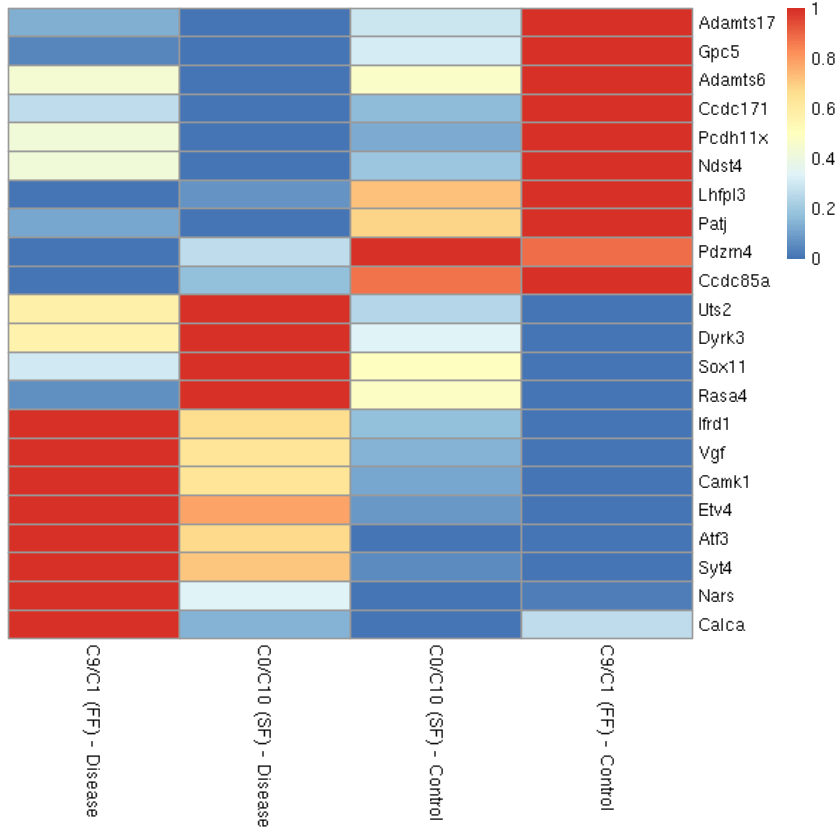

In [27]:
alpha_keep <- subset(
  alpha_subset,
  subset = seurat_clusters %in% c(9, 1, 0, 10) &
           stage %in% c("ctl", "sod.mid", "sod.end"))

# Map clusters to groups
group <- ifelse(alpha_keep$seurat_clusters %in% c(9, 1),  "C9/C1 (FF)",
         ifelse(alpha_keep$seurat_clusters %in% c(0, 10), "C0/C10 (SF)", NA_character_))

# Map stage to Control/Disease
status <- ifelse(alpha_keep$stage == "ctl", "Control", "Disease")

# Combine
alpha_keep$condition <- ifelse(is.na(group), NA_character_, paste(group, status, sep = " - "))


all.markers <- c("Etv4","Vgf","Nars","Camk1","Uts2","Atf3","Sox11","Syt4","Calca","Ifrd1","Dyrk3","Rasa4",
                 "Ccdc171","Pcdh11x","Adamts17","Gpc5","Pdzrn4","Lhfpl3","Ndst4","Patj","Adamts6","Ccdc85a")
length(all.markers)

Idents(alpha_keep) <- alpha_keep$condition
heatmap.avgexp <- AverageExpression(alpha_keep, features = all.markers)$RNA
heatmap.avgexp <- (heatmap.avgexp - rowMins(heatmap.avgexp)) / (rowMaxs(heatmap.avgexp) - rowMins(heatmap.avgexp))
pheatmap(heatmap.avgexp)


col_order <- c("C9/C1 (FF) - Disease", "C0/C10 (SF) - Disease", "C0/C10 (SF) - Control", "C9/C1 (FF) - Control")
heatmap.avgexp <- heatmap.avgexp[, col_order]

row_order <- c("Adamts17","Gpc5","Adamts6","Ccdc171","Pcdh11x","Ndst4","Lhfpl3","Patj","Pdzrn4","Ccdc85a",
               "Uts2","Dyrk3","Sox11","Rasa4","Ifrd1","Vgf","Camk1","Etv4","Atf3","Syt4","Nars","Calca")
heatmap.avgexp <- heatmap.avgexp[row_order, ]

pheatmap(heatmap.avgexp, cluster_rows = FALSE, cluster_cols = FALSE)

## C9/C1 GO Plots


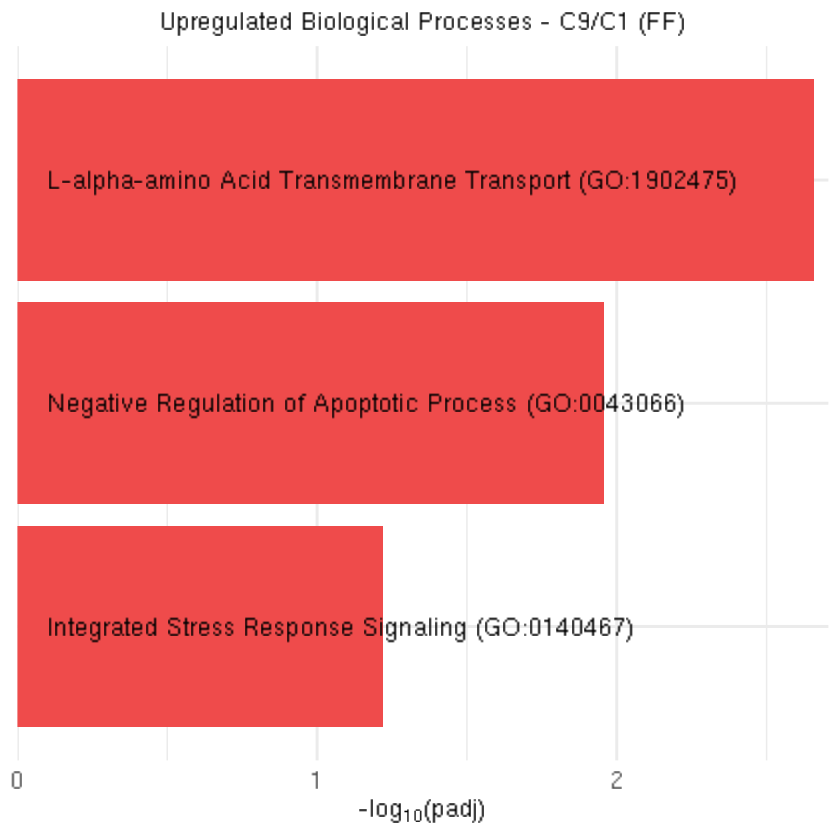

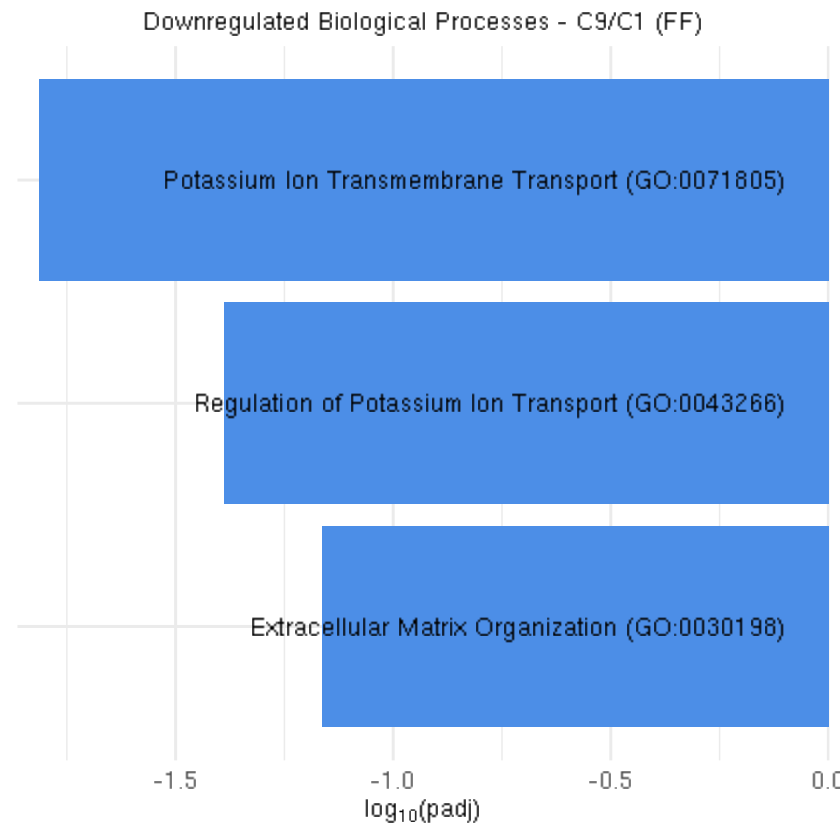

In [28]:
light_firebrick3  <- lighten("firebrick3",  0.2)
light_dodgerblue3 <- lighten("dodgerblue3", 0.2)

C9_C1_up_GO_BP <- read.csv(c9_c1_up_go_file)
C9_C1_down_GO_BP <- read.csv(c9_c1_down_go_file)

up_terms <- c("L-alpha-amino Acid Transmembrane Transport (GO:1902475)",
              "Negative Regulation of Apoptotic Process (GO:0043066)",
              "Integrated Stress Response Signaling (GO:0140467)"
              )

down_terms <- c("Potassium Ion Transmembrane Transport (GO:0071805)",
              "Regulation of Potassium Ion Transport (GO:0043266)",
              "Extracellular Matrix Organization (GO:0030198)"
               )

# Get selected, significant terms
up_terms_df <- C9_C1_up_GO_BP %>%
  dplyr::filter(Term %in% up_terms)

up_terms_df$Term <- fct_reorder(up_terms_df$Term, up_terms_df$Adjusted.P.value, .desc = TRUE)

# Get selected, significant terms
down_terms_df <- C9_C1_down_GO_BP %>%
  dplyr::filter(Term %in% down_terms)

down_terms_df$Term <- fct_reorder(down_terms_df$Term, down_terms_df$Adjusted.P.value, .desc = TRUE)

C9_C1_up_GO_BP_plot <- ggplot(up_terms_df, aes(x = -log10(Adjusted.P.value), y = Term)) +
  geom_col(fill = light_firebrick3) +
  geom_text(aes(x = 0.1, y = Term, label = Term),
            hjust = 0, vjust = 0.5, color = "black",
            inherit.aes = FALSE, size = 5) +
  scale_x_continuous(expand = expansion(add = c(0, 0.05))) +
  ggtitle("Upregulated Biological Processes - C9/C1 (FF)") +
  labs(x = expression("-log"[10]*"(padj)"), y = NULL) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.y    = element_blank(),
    plot.title     = element_text(hjust = 0.5, size = 14),
    axis.title.x   = element_text(size = 14),
    axis.text.x    = element_text(size = 14)
  )

C9_C1_up_GO_BP_plot

C9_C1_down_GO_BP_plot <- ggplot(down_terms_df, aes(x = log10(Adjusted.P.value), y = Term)) +
  geom_col(fill = light_dodgerblue3) +
  geom_text(
    aes(x = -0.1, y = Term, label = Term),
    hjust = 1, vjust = 0.5, color = "black",
    inherit.aes = FALSE,
    size = 5
  ) +
  scale_x_continuous(expand = expansion(add = c(0.05, 0))) +
  ggtitle("Downregulated Biological Processes - C9/C1 (FF)") +
  labs(x = expression("log"[10]*"(padj)"), y = NULL) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.y  = element_blank(),
    axis.text.x  = element_text(size = 14),
    axis.title.x = element_text(size = 14),
    plot.title   = element_text(hjust = 0.5, size = 14)
  )

C9_C1_down_GO_BP_plot

## Selected FF DEG Heatmap

[1] 44

Warning message:
“The following 24 features were not found in the integrated assay: Slc7a5, Slc3a2, Slc7a1, Slc38a2, Slc7a3, Hspa9, Rhbdd1, Anxa5, Asns, Vegfa, Hax1, Mapk7, Lonp1, Spry2, Atf5, Mcl1, Ltf, Fosl1, Cebpg, Kcnj2, Kcnj3, Dpp6, Dlg1, Adamts17”


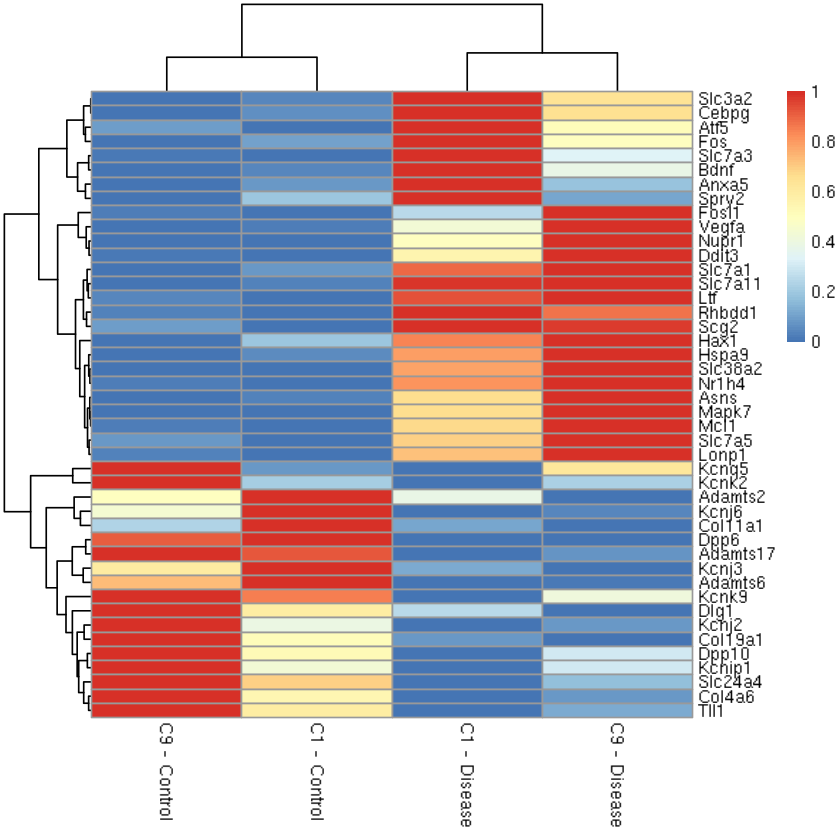

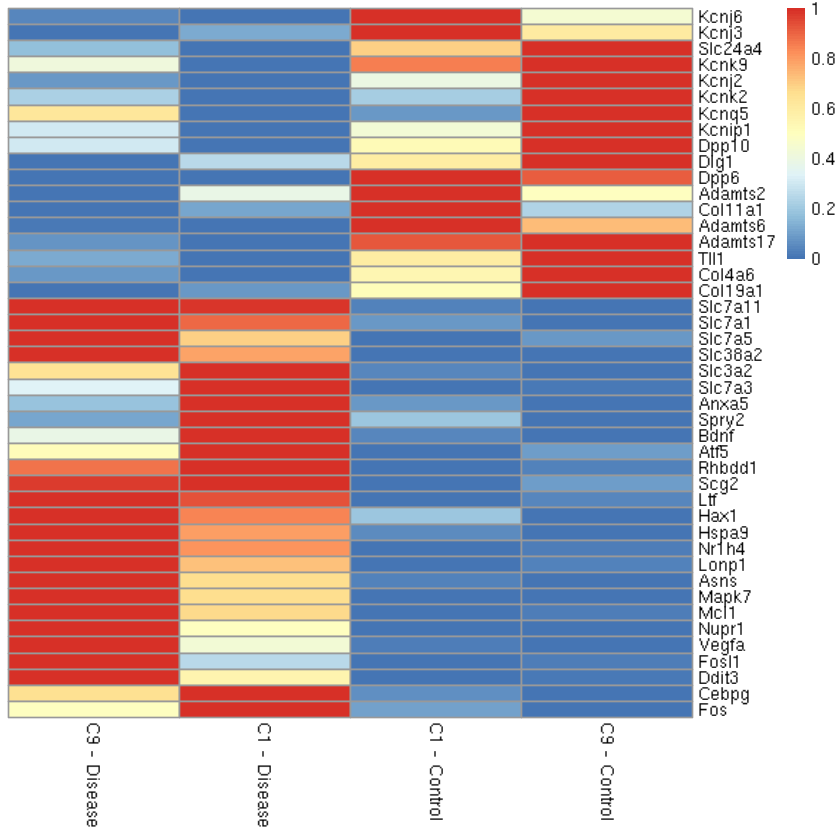

In [29]:
alpha_keep <- subset(
  alpha_subset,
  subset = seurat_clusters %in% c(9, 1) &
           stage %in% c("ctl","sod.mid","sod.end"))

# Map clusters to groups
group <- ifelse(alpha_keep$seurat_clusters == 9, "C9",
         ifelse(alpha_keep$seurat_clusters == 1, "C1", NA_character_))

# Map stage to Control/Disease
status <- ifelse(alpha_keep$stage == "ctl", "Control", "Disease")

# Combine 
alpha_keep$condition <- ifelse(is.na(group), NA_character_, paste(group, status, sep = " - "))

all.markers <- c("Slc7a5","Slc3a2","Slc7a11","Slc7a1","Slc38a2","Slc7a3",
                 "Hspa9","Bdnf","Rhbdd1","Anxa5","Nr1h4","Asns","Vegfa","Hax1",
                 "Mapk7","Lonp1","Spry2","Nupr1","Atf5","Scg2","Mcl1","Ltf",
                 "Fosl1","Ddit3","Cebpg","Fos",
                 "Slc24a4","Kcnj6","Kcnk9","Kcnq5","Kcnk2","Kcnj2","Kcnj3",
                 "Dpp10","Dpp6","Dlg1","Kcnip1",
                 "Adamts2","Col11a1","Adamts17","Col4a6","Tll1","Adamts6","Col19a1"
                 )
length(all.markers)

Idents(alpha_keep) <- alpha_keep$condition
heatmap.avgexp <- AverageExpression(alpha_keep, features=all.markers)$RNA
heatmap.avgexp <- (heatmap.avgexp - rowMins(heatmap.avgexp))/(rowMaxs(heatmap.avgexp) - rowMins(heatmap.avgexp))
pheatmap(heatmap.avgexp)

col_order <- c('C9 - Disease','C1 - Disease','C1 - Control','C9 - Control') 
heatmap.avgexp <- heatmap.avgexp[,col_order]

row_order <- c("Kcnj6","Kcnj3","Slc24a4","Kcnk9","Kcnj2","Kcnk2","Kcnq5",
               "Kcnip1","Dpp10","Dlg1","Dpp6",
               "Adamts2","Col11a1","Adamts6","Adamts17","Tll1","Col4a6","Col19a1",
               "Slc7a11","Slc7a1","Slc7a5","Slc38a2","Slc3a2","Slc7a3",
               "Anxa5","Spry2","Bdnf","Atf5","Rhbdd1","Scg2",
               "Ltf","Hax1","Hspa9","Nr1h4","Lonp1","Asns","Mapk7","Mcl1","Nupr1","Vegfa",
               "Fosl1","Ddit3","Cebpg","Fos")
heatmap.avgexp <- heatmap.avgexp[row_order,]

pheatmap(heatmap.avgexp, cluster_rows = FALSE, cluster_cols = FALSE)